In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import linregress
from tabulate import tabulate

In [8]:
class UVvisWorkup():
    def __init__(self, size=1): # size= # of spectra
        self.size = size
        self.dfs = [None] * size      # store each spectrum here
        self.A = np.zeros(size)       # peak absorbance values
        self.peakWL = np.zeros(size) # peak wavelengths

    def formatspec(self, path):
    # Try common instrument encodings
        for enc in ("utf-16", "utf-16le", "utf-8-sig", "cp1252", "latin1"):
            try:
                df = pd.read_csv(path, encoding=enc)
                break
            except UnicodeDecodeError:
                df = None
        if df is None:
            raise UnicodeDecodeError("Could not decode file with common encodings.")

        # If it's a weird single-column file with comma-separated values
        if df.shape[1] == 1:
            df = df.iloc[:, 0].astype(str).str.split(",", expand=True)

        df = df.iloc[:, :3].copy()
        df.columns = ["Wavelength (nm)", "Absorbance (AU)", "Std.Dev."]

        df["Wavelength (nm)"] = pd.to_numeric(df["Wavelength (nm)"], errors="coerce")
        df["Absorbance (AU)"] = pd.to_numeric(df["Absorbance (AU)"], errors="coerce")
        df = df.dropna(subset=["Wavelength (nm)", "Absorbance (AU)"]).reset_index(drop=True)

        return df
        
    def load(self,i,path):
        self.dfs[i] = self.formatspec(path)
    def plot(self,i): # plots single spectrum
        df=self.dfs[i]
        plt.plot(df["Wavelength (nm)"], df["Absorbance (AU)"])
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Absorbance (AU)")
        #plt.title(f"Spectrum {i}")
        plt.show()
    def peak(self,i,WLmin,WLmax):
        df=self.dfs[i]

        window=df[(df["Wavelength (nm)"] >= WLmin) & (df["Wavelength (nm)"] <= WLmax)]
        idx = window["Absorbance (AU)"].idxmax()
        
        self.A[i] = float(df.loc[idx, "Absorbance (AU)"])
        self.peakWL[i] = float(df.loc[idx, "Wavelength (nm)"])

        return self.peakWL[i], self.A[i]
    def Abs(self):
        return self.A

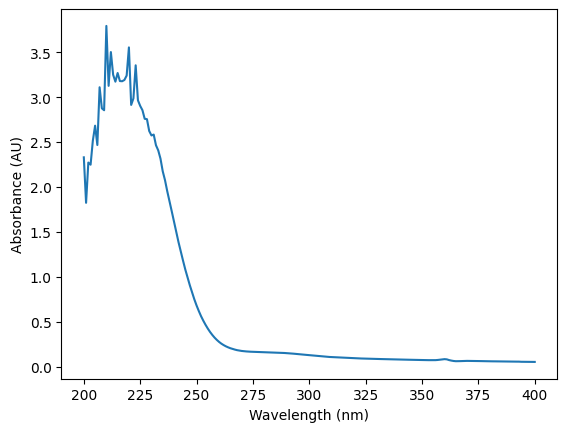

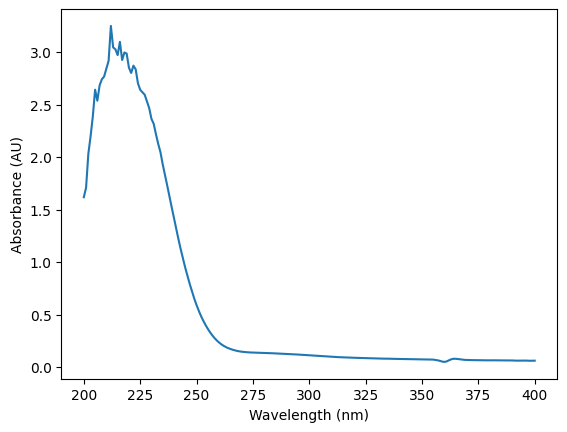

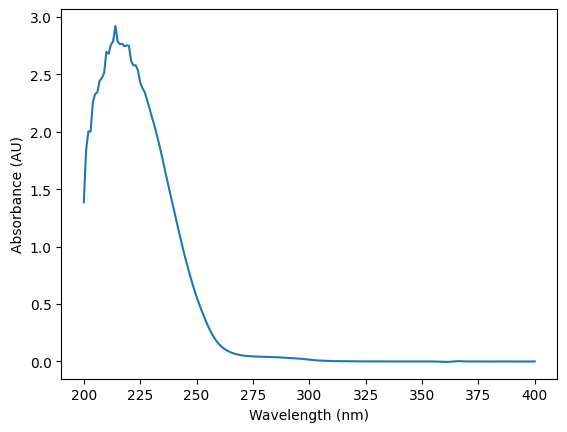

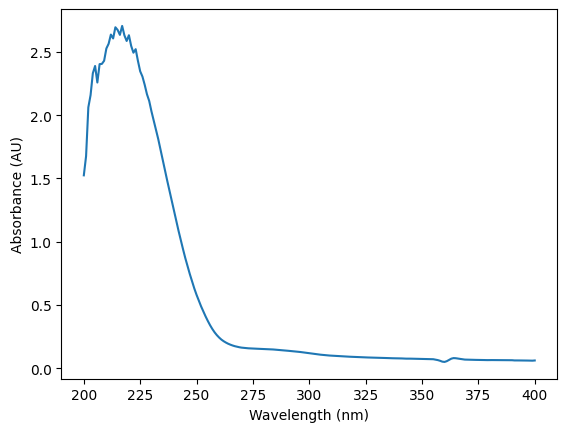

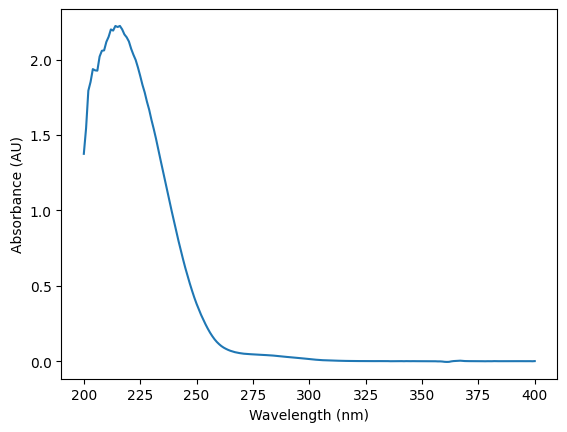

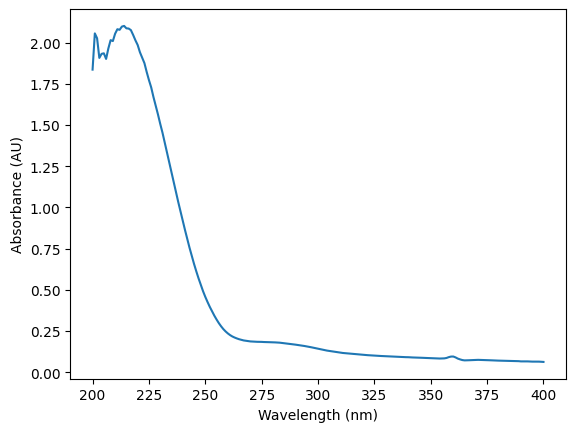

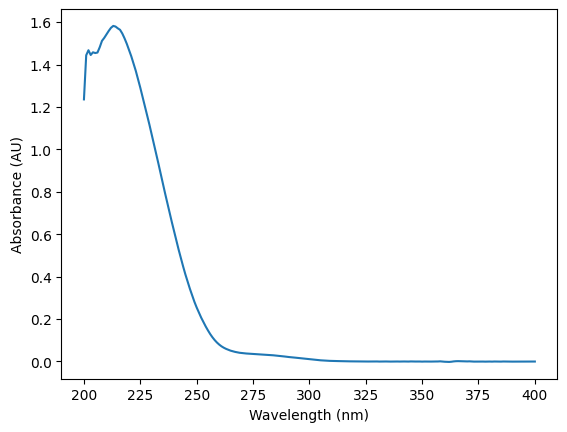

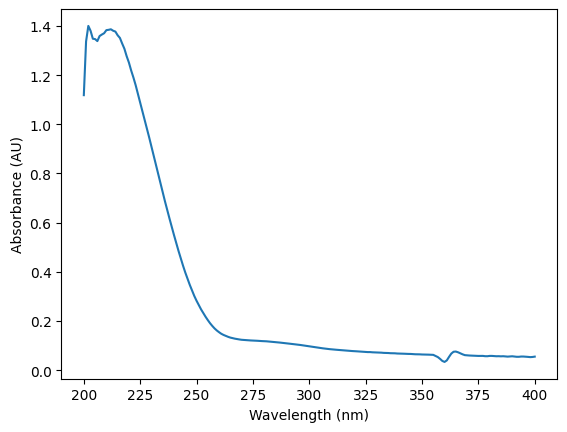

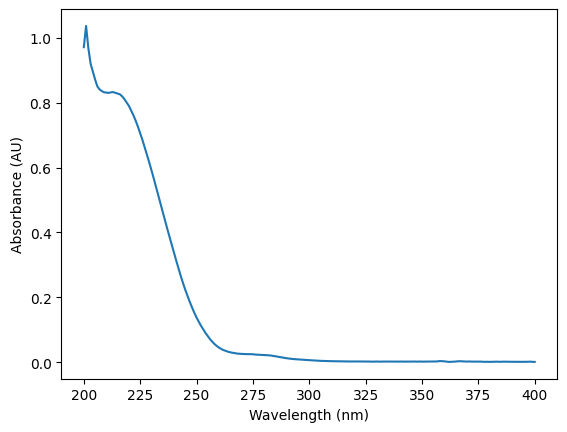

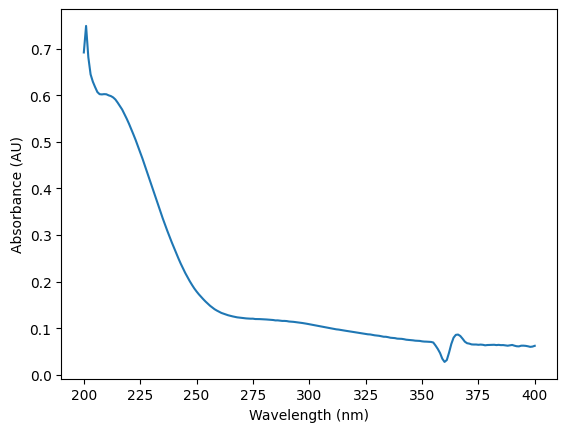

╒═════════════════════╤═════════════════════════╤══════════════╕
│   Concentration (M) │   Wavelength of Max Abs │   Absorbance │
╞═════════════════════╪═════════════════════════╪══════════════╡
│            0.00278  │                     210 │     3.79236  │
├─────────────────────┼─────────────────────────┼──────────────┤
│            0.002502 │                     212 │     3.24945  │
├─────────────────────┼─────────────────────────┼──────────────┤
│            0.002224 │                     214 │     2.92156  │
├─────────────────────┼─────────────────────────┼──────────────┤
│            0.001946 │                     217 │     2.70482  │
├─────────────────────┼─────────────────────────┼──────────────┤
│            0.001668 │                     216 │     2.22344  │
├─────────────────────┼─────────────────────────┼──────────────┤
│            0.00139  │                     214 │     2.10119  │
├─────────────────────┼─────────────────────────┼──────────────┤
│            0.001112 │  

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

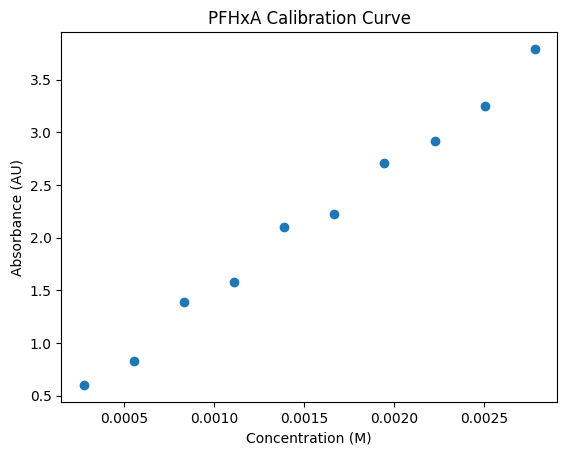

In [11]:
uv= UVvisWorkup(size=10)

C1=27.8e-4 
C2=(C1*9)/10
C3=(C1*8)/10
C4=(C1*7)/10
C5=(C1*6)/10
C6=(C1*5)/10
C7=(C1*4)/10
C8=(C1*3)/10
C9=(C1*2)/10
C10=(C1/10) 

path1= "Std 1 PFHxA 28.7 mM quartz.CSV"
path2= "Std 2.CSV"
path3= "Std 3.CSV"
path4= "Std 4.CSV"
path5= "Std 5.CSV"
path6= "Std 6.CSV"
path7= "Std 7.CSV"
path8= "Std 8.CSV"
path9= "Std 9.CSV"
path10= "Std 10.CSV"

conc=[C1, C2, C3, C4, C5, C6, C7, C8, C9, C10]
spectra=[path1, path2, path3, path4, path5, path6, path7, path8, path9, path10]

for i, path in enumerate(spectra):
    uv.load(i,path)
    uv.plot(i)
    uv.peak(i, 210, 220)
    #plt.title(f"{conc[i]}M")

data=[]
for i in range(uv.size):
    data.append ([conc[i], uv.peakWL[i],uv.A[i]])
    
headers = ["Concentration (M)", "Wavelength of Max Abs", "Absorbance"]
print(tabulate(data, headers=headers,tablefmt="fancy_grid"))
x=np.array(conc)
y=uv.Abs()

lin=linregress(x,y)
slope=lin.slope
intercept=lin.intercept
r_val=lin.rvalue
p_val=lin.pvalue
std_err=lin.stderr

print(f"Slope (ε·l) = {slope:.3e}")
print(f"Intercept = {intercept:.3e}")
print(f"R² = {r_val**2:.5f}")
print(f"Std error = {std_err:.3e}")

plt.scatter(conc,uv.Abs())
plt.xlabel("Concentration (M)")
plt.ylabel("Absorbance (AU)")
plt.title("PFHxA Calibration Curve")

plt.plot


In [18]:
uv= UVvisWorkup()

C1=2.87e-4 #previously Std. B
C2=(C1*9)/10
C3=(C1*8)/10
C4=(C1*7)/10
C5=(C1*6)/10
C6=(C1*5)/10
C7=(C1*4)/10
C8=(C1*3)/10
C9=(C1*2)/10
C10=(C1/10)  #previously Std. C

#path1="PFAA standards (A).CSV"
path1= "pfhxa std B.CSV"
path10= "pfhxa std C.CSV"
#path3=

#conc = [C1, C2, C3, C4, C5, C6, C7, C8, C9, C10] # size=10
#spectra = [path1, path2, path3, path4, path5, path6, path7, path8, path9, path10] #size=10

conc=[C1, C10]
spectra=[path1, path10]

#data= pd.concat(conc,spectra)
A=np.zeros(len(spectra)) #0 to be overwritten with absorbance values

for x in spectra:
    uv.plot(x)
    uv.Abs(x)
    a[i]=uv.Abs(x)
    

#pd.concat([conc,spectra])

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte